In [22]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import pandas_datareader as data 

plt.style.use("fivethirtyeight")
%matplotlib inline 
print("hello")
    

hello


In [69]:
import yfinance as yf
import datetime as dt
stock="RELIANCE.NS"
# start=dt.datetime(2000,1,1)
# end=dt.datetime(2025,7,1)
# df=yf.download(stock,start,end)
df = yf.download(stock, start='2015-01-01', end='2024-12-31')
df = df.reset_index()
df = df[['Date', 'Open', 'High', 'Low', 'Close', 'Volume']]

C:\Users\Sidhesh Salunke\AppData\Local\Temp\ipykernel_18448\1018668869.py:7: FutureWarning:

YF.download() has changed argument auto_adjust default to True

[*********************100%***********************]  1 of 1 completed


In [70]:
df.head()

Price,Date,Open,High,Low,Close,Volume
Ticker,,RELIANCE.NS,RELIANCE.NS,RELIANCE.NS,RELIANCE.NS,RELIANCE.NS
0,2015-01-01,190.414914,191.639510,189.845568,190.758652,2963643
1,2015-01-02,190.801616,192.509623,189.985223,190.253769,7331366
2,2015-01-05,190.135595,191.403172,187.793807,188.169785,10103941
3,2015-01-06,186.913006,187.557530,178.748979,179.629837,18627980
4,2015-01-07,179.844662,184.506740,179.823178,183.539948,20720312


In [71]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2466 entries, 0 to 2465
Data columns (total 6 columns):
 #   Column                 Non-Null Count  Dtype         
---  ------                 --------------  -----         
 0   (Date, )               2466 non-null   datetime64[ns]
 1   (Open, RELIANCE.NS)    2466 non-null   float64       
 2   (High, RELIANCE.NS)    2466 non-null   float64       
 3   (Low, RELIANCE.NS)     2466 non-null   float64       
 4   (Close, RELIANCE.NS)   2466 non-null   float64       
 5   (Volume, RELIANCE.NS)  2466 non-null   int64         
dtypes: datetime64[ns](1), float64(4), int64(1)
memory usage: 115.7 KB


In [72]:
df.isnull().sum()

Price   Ticker     
Date                   0
Open    RELIANCE.NS    0
High    RELIANCE.NS    0
Low     RELIANCE.NS    0
Close   RELIANCE.NS    0
Volume  RELIANCE.NS    0
dtype: int64

In [73]:
df.describe()

Price,Date,Open,High,Low,Close,Volume
Ticker,,RELIANCE.NS,RELIANCE.NS,RELIANCE.NS,RELIANCE.NS,RELIANCE.NS
count,2466,2466.000000,2466.000000,2466.000000,2466.000000,2.466000e+03
mean,2019-12-31 17:36:56.058394112,733.951715,741.443070,726.039682,733.420515,1.843374e+07
min,2015-01-01 00:00:00,175.440384,175.676704,171.111302,174.183548,1.705656e+06
25%,2017-07-04 06:00:00,316.954881,318.816665,314.251732,316.690933,1.071503e+07
50%,2020-01-06 12:00:00,647.614634,654.643678,639.024844,644.537994,1.464605e+07
75%,2022-06-28 18:00:00,1127.085971,1137.990951,1116.306733,1125.537292,2.109906e+07
max,2024-12-30 00:00:00,1599.022925,1603.358288,1580.137072,1595.484985,1.426834e+08
std,NaN,421.808844,425.424482,417.910560,421.500900,1.355283e+07


In [74]:
df.columns

MultiIndex([(  'Date',            ''),
            (  'Open', 'RELIANCE.NS'),
            (  'High', 'RELIANCE.NS'),
            (   'Low', 'RELIANCE.NS'),
            ( 'Close', 'RELIANCE.NS'),
            ('Volume', 'RELIANCE.NS')],
           names=['Price', 'Ticker'])

In [75]:
df.to_csv("RELIANCE.csv")

In [76]:
data01=pd.read_csv("RELIANCE.csv")

In [77]:
data01.head()

,Price,Date,Open,High,Low,Close,Volume
0,Ticker,NaN,RELIANCE.NS,RELIANCE.NS,RELIANCE.NS,RELIANCE.NS,RELIANCE.NS
1,0,2015-01-01,190.41491353533632,191.63950954902654,189.845568461702,190.75865173339844,2963643
2,1,2015-01-02,190.8016160069897,192.50962251793305,189.98522345788643,190.25376892089844,7331366
3,2,2015-01-05,190.13559455282044,191.4031720671145,187.79380658453923,188.16978454589844,10103941
4,3,2015-01-06,186.913006243564,187.55752979610384,178.74897909801405,179.6298370361328,18627980


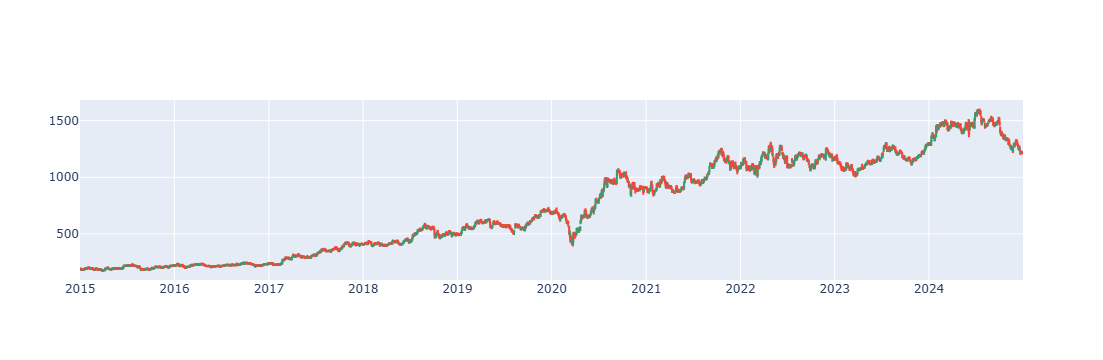

In [78]:
import plotly.graph_objects as go 
fig=go.Figure(data=[go.Candlestick(x=data01['Date'],open=data01['Open'],high=data01['High'],low=data01['Low'],close=data01['Close'])])
fig.update_layout(xaxis_rangeslider_visible=False)
fig.show()

In [79]:
df=df.drop(['Date'],axis=1)

C:\Users\Sidhesh Salunke\AppData\Local\Temp\ipykernel_18448\1039762504.py:1: PerformanceWarning:

dropping on a non-lexsorted multi-index without a level parameter may impact performance.



In [80]:
df.head()

Price,Open,High,Low,Close,Volume
Ticker,RELIANCE.NS,RELIANCE.NS,RELIANCE.NS,RELIANCE.NS,RELIANCE.NS
0,190.414914,191.639510,189.845568,190.758652,2963643
1,190.801616,192.509623,189.985223,190.253769,7331366
2,190.135595,191.403172,187.793807,188.169785,10103941
3,186.913006,187.557530,178.748979,179.629837,18627980
4,179.844662,184.506740,179.823178,183.539948,20720312


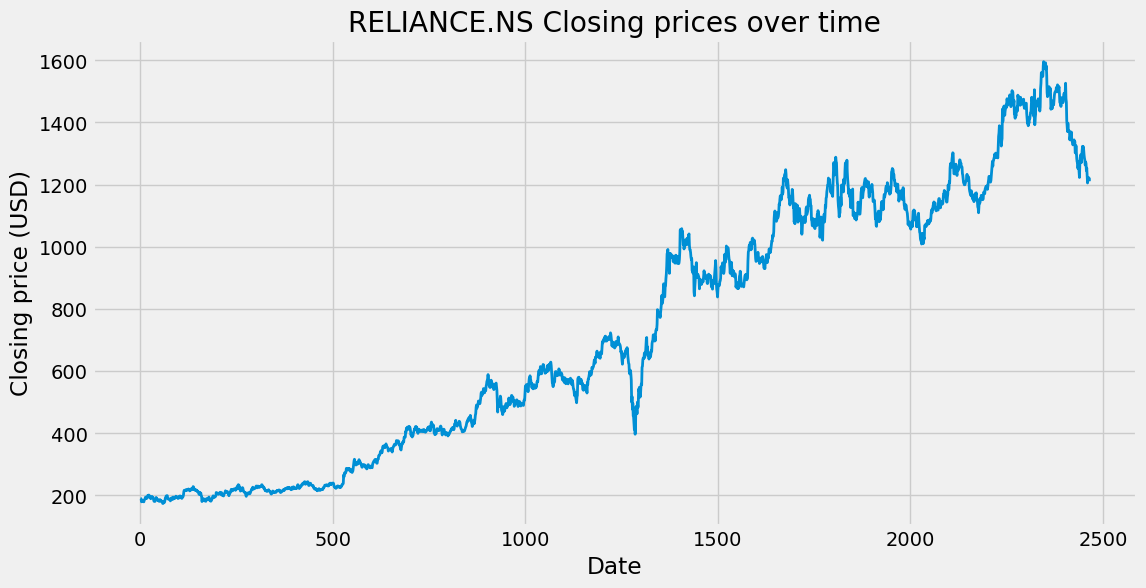

In [81]:
plt.figure(figsize=(12,6))
plt.plot(df['Close'],label=f'{stock} Closing Price ',linewidth=2)
plt.title(f'{stock} Closing prices over time')
plt.xlabel('Date')
plt.ylabel('Closing price (USD)')
plt.show()

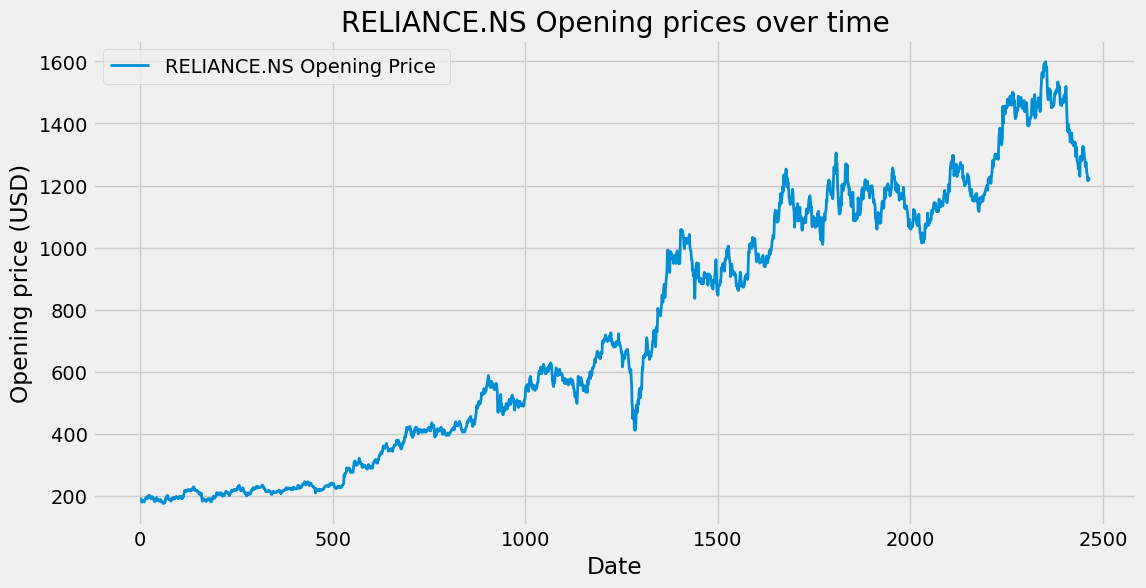

In [82]:
plt.figure(figsize=(12,6))
plt.plot(df['Open'],label=f'{stock} Opening Price ',linewidth=2)
plt.title(f'{stock} Opening prices over time')
plt.xlabel('Date')
plt.ylabel('Opening price (USD)')
plt.legend()
plt.show()

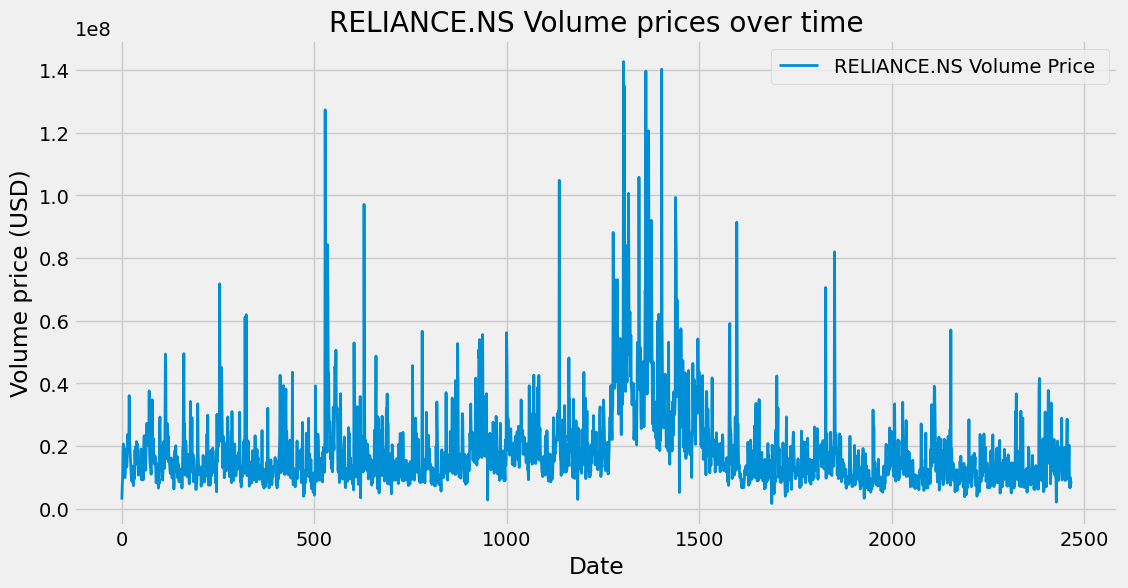

In [83]:
plt.figure(figsize=(12,6))
plt.plot(df['Volume'],label=f'{stock} Volume Price ',linewidth=2)
plt.title(f'{stock} Volume prices over time')
plt.xlabel('Date')
plt.ylabel('Volume price (USD)')
plt.legend()
plt.show()

In [84]:
# moving average ma
ma100=df.Close.rolling(100).mean()
ma200=df.Close.rolling(200).mean()

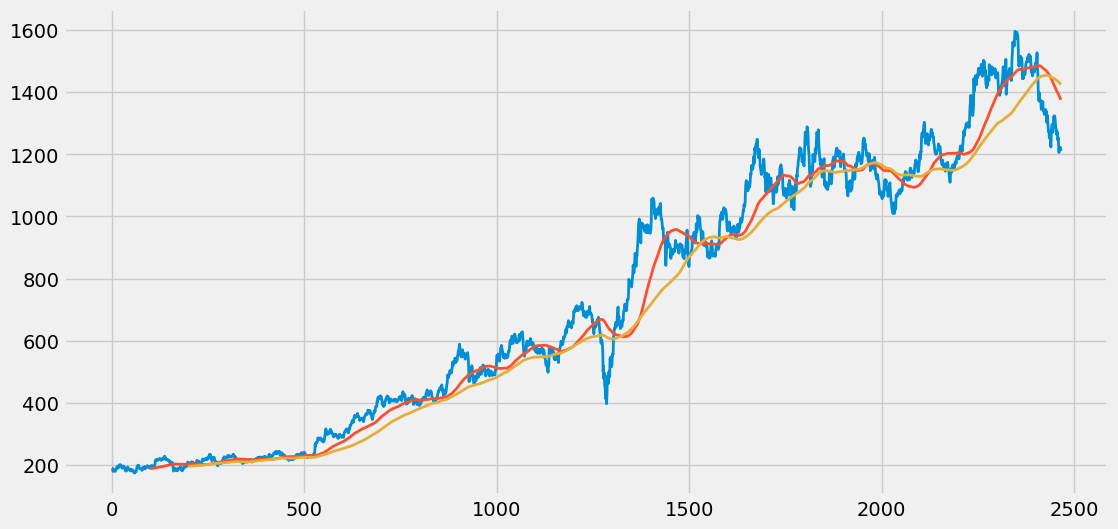

In [85]:
plt.figure(figsize=(12,6))
plt.plot(df['Close'],label=f'{stock} Closing Price ',linewidth=2)
plt.plot(ma100,label=f'{stock} Moving average 100 Price ',linewidth=2)
plt.plot(ma200,label=f'{stock} Moving average 200 Price ',linewidth=2)

plt.show()

In [86]:
ema100=df.Close.ewm(span=100,adjust=False).mean()
ema200=df.Close.ewm(span=200,adjust=False).mean()

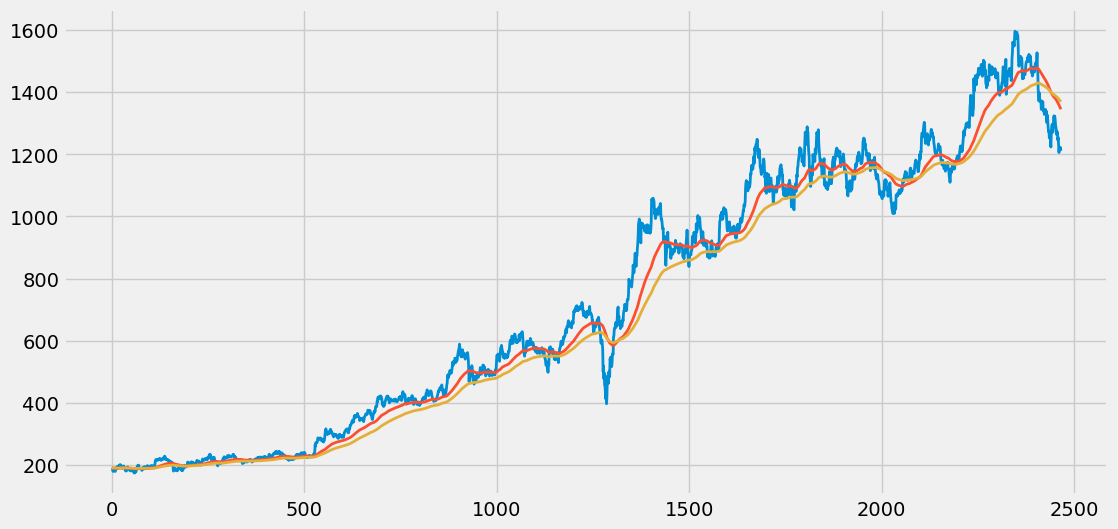

In [87]:
plt.figure(figsize=(12,6))
plt.plot(df['Close'],label=f'{stock} Closing Price ',linewidth=2)
plt.plot(ema100,label=f'{stock} EXP. Moving average 100 Price ',linewidth=2)
plt.plot(ema200,label=f'{stock} EXP. Moving average 200 Price ',linewidth=2)

plt.show()

In [88]:
#Training And Testing 
data_training=pd.DataFrame(df['Close'][0:int(len(df)*0.70)])
data_testing=pd.DataFrame(df['Close'][int(len(df)*0.70):int(len(df))])

In [50]:
data_training.shape

(3059, 1)

In [51]:
data_testing.shape

(1312, 1)

In [62]:
from sklearn.preprocessing import MinMaxScaler
scaler=MinMaxScaler(feature_range=(0,1))


In [63]:
data_training_arr=scaler.fit_transform(data_training)

In [64]:
data_training_arr

array([[0.2536469 ],
       [0.22298306],
       [0.26168495],
       ...,
       [0.78952066],
       [0.73206295],
       [0.73474231]])

In [65]:
x_train=[]
y_train=[]

for i in range (100,data_training_arr.shape[0]):
    x_train.append(data_training_arr[i-100:i])
    y_train.append(data_training_arr[i,3])
x_train,y_train=np.array(x_train),np.array(y_train)

In [66]:
x_train.shape

(2959, 100, 1)

In [67]:
x_train

array([[[0.2536469 ],
        [0.22298306],
        [0.26168495],
        ...,
        [0.25721937],
        [0.26228043],
        [0.26466204]],

       [[0.22298306],
        [0.26168495],
        [0.26734149],
        ...,
        [0.26228043],
        [0.26466204],
        [0.30038698]],

       [[0.26168495],
        [0.26734149],
        [0.33581412],
        ...,
        [0.26466204],
        [0.30038698],
        [0.31854715]],

       ...,

       [[0.83596311],
        [0.85293236],
        [0.83685608],
        ...,
        [0.79607017],
        [0.82792492],
        [0.82137541]],

       [[0.85293236],
        [0.83685608],
        [0.83179516],
        ...,
        [0.82792492],
        [0.82137541],
        [0.78952066]],

       [[0.83685608],
        [0.83179516],
        [0.86067283],
        ...,
        [0.82137541],
        [0.78952066],
        [0.73206295]]])

In [72]:
## Model Building 
from keras.layers import Dense,Dropout,LSTM,Input
from keras.models import Sequential

In [75]:
model=Sequential()

model.add(Input(shape=(x_train.shape[1], 1)))
model.add(LSTM(units=50, activation='relu', return_sequences=True))
model.add(Dropout(0.2))

model.add(LSTM(units=60,activation='relu',return_sequences=True))
model.add(Dropout(0.3))


model.add(LSTM(units=80,activation='relu',return_sequences=True))
model.add(Dropout(0.4))

model.add(LSTM(units=120,activation='relu'))
model.add(Dropout(0.5))

model.add(Dense(units=1))

In [77]:
model.summary()

Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ lstm_8 (LSTM)                        │ (None, 100, 50)             │          10,400 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_8 (Dropout)                  │ (None, 100, 50)             │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ lstm_9 (LSTM)                        │ (None, 100, 60)             │          26,640 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_9 (Dropout)                  │ (None, 100, 60)             │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ lstm_10 (LSTM)                       │ (None, 100, 80)             │          45,120 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_10 (Dropout)                 │ (None, 100, 80)             │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ lstm_11 (LSTM)                       │ (None, 120)                 │          96,480 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_11 (Dropout)                 │ (None, 120)                 │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_2 (Dense)                      │ (None, 1)                   │             121 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 178,761 (698.29 KB)

 Trainable params: 178,761 (698.29 KB)

 Non-trainable params: 0 (0.00 B)

In [78]:
model.compile(optimizer='adam',loss="mean_squared_error")
model.fit(x_train,y_train,epochs=50)

Epoch 1/50
93/93 ━━━━━━━━━━━━━━━━━━━━ 29s 212ms/step - loss: 0.0965
Epoch 2/50
93/93 ━━━━━━━━━━━━━━━━━━━━ 22s 231ms/step - loss: 0.0105
Epoch 3/50
93/93 ━━━━━━━━━━━━━━━━━━━━ 20s 219ms/step - loss: 0.0089
Epoch 4/50
93/93 ━━━━━━━━━━━━━━━━━━━━ 19s 204ms/step - loss: 0.0074
Epoch 5/50
93/93 ━━━━━━━━━━━━━━━━━━━━ 21s 222ms/step - loss: 0.0071
Epoch 6/50
93/93 ━━━━━━━━━━━━━━━━━━━━ 21s 225ms/step - loss: 0.0064
Epoch 7/50
93/93 ━━━━━━━━━━━━━━━━━━━━ 21s 229ms/step - loss: 0.0060
Epoch 8/50
93/93 ━━━━━━━━━━━━━━━━━━━━ 22s 234ms/step - loss: 0.0065
Epoch 9/50
93/93 ━━━━━━━━━━━━━━━━━━━━ 24s 257ms/step - loss: 0.0053
Epoch 10/50
93/93 ━━━━━━━━━━━━━━━━━━━━ 29s 312ms/step - loss: 0.0051
Epoch 11/50
93/93 ━━━━━━━━━━━━━━━━━━━━ 30s 319ms/step - loss: 0.0046
Epoch 12/50
93/93 ━━━━━━━━━━━━━━━━━━━━ 26s 284ms/step - loss: 0.0056
Epoch 13/50
93/93 ━━━━━━━━━━━━━━━━━━━━ 28s 298ms/step - loss: 0.0049
Epoch 14/50
93/93 ━━━━━━━━━━━━━━━━━━━━ 27s 290ms/step - loss: 0.0045
Epoch 15/50
93/93 ━━━━━━━━━━━━━━━━━━━━ 25s 

In [79]:
past_100days=data_training.tail(100)


In [81]:
final_df = pd.concat([past_100days, data_testing], ignore_index=True)


In [82]:
final_df.head()

Ticker,POWERGRID.NS
0,102.683975
1,105.203033
2,106.501518
3,107.124786
4,106.008087


In [83]:
input_data=scaler.fit_transform(final_df)

In [84]:
x_test=[]
y_test=[]

for i in range (100,input_data.shape[0]):
    x_test.append(input_data[i-100:i])
    y_test.append(input_data[i,0])
x_test,y_test=np.array(x_test),np.array(y_test)

In [85]:
x_test.shape

(1312, 100, 1)

In [86]:
y_predicted=model.predict(x_test)

41/41 ━━━━━━━━━━━━━━━━━━━━ 7s 83ms/step


In [87]:
y_predicted.shape

(1312, 1)

In [88]:
scaler.scale_

array([0.00355564])

In [89]:
scaler_factor=1 / 0.00355564
y_predicted=y_predicted*scaler_factor
y_test=y_test*scaler_factor 

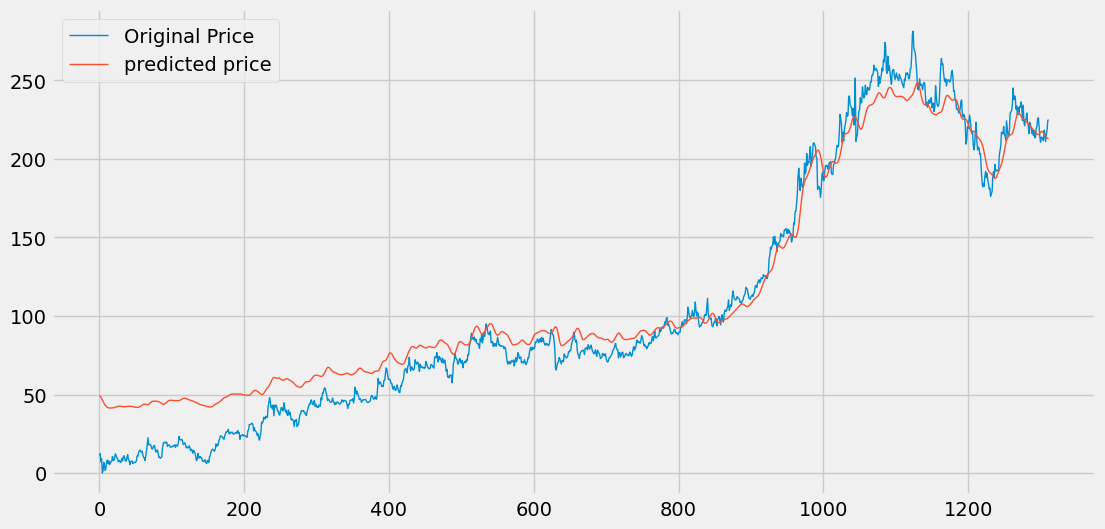

In [94]:
plt.figure(figsize=(12,6))
plt.plot(y_test,label="Original Price",linewidth=1)
plt.plot(y_predicted,label="predicted price" ,linewidth=1)
plt.legend()
plt.show()

In [95]:
model.save("stock_dl_model_new.keras")